# Model Visualization — 3D Molecular System with PBC

Load a trained flow from a fab-torch `run.py` / `setup_run.py` experiment and
visualize it for a **triatomic solute in explicit TIP3P water** (`SoluteInWater`).

**Atom layout**
```
[sol_0, sol_1, sol_2,  O_0, H1_0, H2_0,  O_1, H1_1, H2_1,  ...]
  ^^^^ solute (3 atoms)       ^^^^ water molecule 0 (O + 2H) ...
```

**Layout**
1. Configuration (paths, device, sample count)
2. Imports
3. Load config + build target (`SoluteInWater`)
4. Reconstruct flow and load checkpoint
5. Generate flow samples
6. Visualization
   - 6.1 Position density scatter (XY / XZ / YZ projections, water O only)
   - 6.2 3-D water-oxygen density heatmaps (XY / XZ / YZ)
   - 6.3 Solute–water and water–water RDF (3-D)
   - 6.4 O–O pairwise distance distributions
   - 6.5 Bond lengths and H–O–H angles
   - 6.6 Energy distributions
   - 6.7 Snapshot gallery (3-D scatter view)
   - 6.8 Animated trajectory *(optional)*


## 1. Configuration

In [33]:
import os

# ── REQUIRED ────────────────────────────────────────────────────────────────
# Directory that contains `config.yaml` and `model_checkpoints/`.
# This is the Hydra output folder produced by setup_run_LJ.py.
RUN_DIR = "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/14-43-19_809112" 

# ── OPTIONAL ────────────────────────────────────────────────────────────────
# Path to the MD reference trajectory (.h5 or .pt) for comparison plots.
# Set to None to skip MD comparison.
MD_REF_PATH = '/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/data/molecules/md/so2/pbc/v10/traj_so2Inwater.h5'

# Number of flow samples to generate
N_SAMPLES = 2000
BATCH_SIZE = 256     # reduce if running out of memory

# Device
DEVICE = "cpu"       # "cuda" if a GPU is available

# fab-torch root (only needed when NOT installed as a package)
FAB_TORCH_PATH = os.path.abspath(os.getcwd())


## 2. Imports

In [34]:
import sys
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc, animation
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
from matplotlib.colors import LogNorm

rc("font", **{"family": "serif"})
rc("mathtext", **{"default": "regular"})

if FAB_TORCH_PATH and FAB_TORCH_PATH not in sys.path:
    sys.path.insert(0, FAB_TORCH_PATH)

from omegaconf import OmegaConf
from fab.target_distributions.solute_in_water import SoluteInWater
from experiments.make_flow import (
    make_shared_water_spline_flow_nf,
    make_perm_equi_spline_flow_nf,
    make_perm_equi_joint_spline_flow_nf,
    make_perm_equi_sfic_flow_nf,
    make_spherical_circular_rqs_flow_nf,
    make_coupled_rqs_flow_nf,
    make_realnvp_flow_nf,
    make_perm_equi_torus_flow_nf,
    make_circ_rqs_torus_flow_nf,
    make_perm_equi_sfic_torus_flow_nf,
)

print("PyTorch", torch.__version__, "| CUDA:", torch.cuda.is_available())


PyTorch 2.5.1 | CUDA: False


## 3. Load config and build target

In [35]:
# Hydra writes config.yaml directly inside the run folder;
# some versions also place it under .hydra/.
for _candidate in [
    os.path.join(RUN_DIR, "config.yaml"),
    os.path.join(RUN_DIR, ".hydra", "config.yaml"),
]:
    if os.path.exists(_candidate):
        config_path = _candidate
        break
else:
    raise FileNotFoundError(f"config.yaml not found under {RUN_DIR}")

cfg = OmegaConf.load(config_path)
print(OmegaConf.to_yaml(cfg))


node:
  name: snellius
  data_dir: /home/${user.username.snellius}/HDD/data
  output_dir: /home/${user.username.snellius}/HDD/results/fab
user:
  name: fleur
  username:
    snellius: fdolmans
    snellius2: fdolmans2
    carbon: fdolmans
    desktop: fleurdolmans
  wandb:
    entity: fleur-dolmans-university-of-amsterdam
target:
  solute_name: so2
  solvent_name: water
  cartesian_dim: 207
  num_solvent_molecules: 22
  temperature: 300.0
  energy_cut: 1000000.0
  energy_max: 10000000000.0
  n_threads: 1
  solute_pdb_path: ${node.data_dir}/molecules/solutes/${target.solute_name}.pdb
  solute_xml_path: ${node.data_dir}/molecules/solutes/${target.solute_name}.xml
  solute_inpcrd_path: null
  solute_prmtop_path: null
  boundary_condition: pbc
  internal_constraints: hbonds
  rigid_water: true
  transform:
    version: LGT
    canonical_sorting: true
  nonbonded_cutoff_nm: 0.4
  box_length_nm: 0.9
  external_constraints: true
  constraint_radius: 0.3
  constraint_force: 10000.0
  equi_step

In [36]:
_platform = "CPU" if DEVICE == "cpu" else "CUDA"

# SoluteInWater needs a writable directory for metrics
_save_dir = os.path.join(RUN_DIR, "viz_metrics")
os.makedirs(_save_dir, exist_ok=True)
cfg.target.solute_pdb_path = "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/data/molecules/solutes/so2.pdb"
cfg.target.solute_xml_path = "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/data/molecules/solutes/so2.xml"

target = SoluteInWater(
    solute_pdb_path=str(cfg.target.solute_pdb_path),
    solute_xml_path=str(OmegaConf.select(cfg, "target.solute_xml_path", default=None) or ""),
    solute_inpcrd_path=str(OmegaConf.select(cfg, "target.solute_inpcrd_path", default=None) or ""),
    solute_prmtop_path=str(OmegaConf.select(cfg, "target.solute_prmtop_path", default=None) or ""),
    dim=int(cfg.target.cartesian_dim),
    num_solvent_molecules=int(cfg.target.num_solvent_molecules),
    temperature=float(cfg.target.temperature),
    energy_cut=float(cfg.target.energy_cut),
    energy_max=float(cfg.target.energy_max),
    n_threads=int(OmegaConf.select(cfg, "target.n_threads", default=1)),
    val_samples_path=MD_REF_PATH,
    device=DEVICE,
    save_dir=_save_dir,
    boundary_condition=str(OmegaConf.select(cfg, "target.boundary_condition", default="pbc")),
    box_length_nm=float(OmegaConf.select(cfg, "target.box_length_nm", default=2.5)),
    nonbonded_cutoff_nm=float(OmegaConf.select(cfg, "target.nonbonded_cutoff_nm", default=1.0)),
    rigid_water=bool(OmegaConf.select(cfg, "target.rigid_water", default=False)),
    internal_constraints=str(OmegaConf.select(cfg, "target.internal_constraints", default="none")),
    external_constraints=bool(OmegaConf.select(cfg, "target.external_constraints", default=False)),
    constraint_radius=float(OmegaConf.select(cfg, "target.constraint_radius", default=1.0)),
    constraint_force=float(OmegaConf.select(cfg, "target.constraint_force", default=10000.0)),
    platform_name=_platform,
    energy_mode=str(OmegaConf.select(cfg, "training.energy_mode", default="full")),
    transform_version=str(OmegaConf.select(cfg, "target.transform.version", default=None)),
    canonical_sorting=bool(OmegaConf.select(cfg, "target.transform.canonical_sorting", default=False)),
)

# ── System constants ─────────────────────────────────────────────────────────
L              = float(target.box_length_nm)           # box side (nm); [0, L)
N_SOLUTE_ATOMS = int(target.system.num_atoms_per_solute)   # = 3  (triatomic)
N_ATOMS_WATER  = int(target.system.num_atoms_per_solvent)  # = 3  (O, H1, H2)
N_WATERS       = int(target.num_solvent_molecules)
N_ATOMS        = target.cartesian_dim // 3             # total atoms

# Indices of water-oxygen atoms in the per-frame (N_ATOMS, 3) array
O_IDX  = [N_SOLUTE_ATOMS + N_ATOMS_WATER * k       for k in range(N_WATERS)]
H1_IDX = [N_SOLUTE_ATOMS + N_ATOMS_WATER * k + 1   for k in range(N_WATERS)]
H2_IDX = [N_SOLUTE_ATOMS + N_ATOMS_WATER * k + 2   for k in range(N_WATERS)]

IS_PBC = (target.boundary_condition == "pbc")

print(f"System  : triatomic solute + {N_WATERS} water molecules  ({N_ATOMS} atoms total)")
print(f"BC      : {target.boundary_condition}  |  box = {L:.3f} nm")
print(f"Internal dim : {target.internal_dim}   Cartesian dim : {target.cartesian_dim}")


Loading MD data...


/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/fab-torch/fab/target_distributions/solute_in_water.py:111: UserWarning: Found path to .pdb, .inpcrd and .prmtop files. Will use .pdb file.
  warnings.warn("Found path to .pdb, .inpcrd and .prmtop files. Will use .pdb file.")


0 HarmonicBondForce False n/a
1 NonbondedForce True False
2 PeriodicTorsionForce False n/a
3 CMMotionRemover False n/a
4 HarmonicAngleForce False n/a
[ForceGroup] group=0 type=HarmonicBondForce name=HarmonicBondForce
[ForceGroup] group=1 type=NonbondedForce name=NonbondedForce
[ForceGroup] group=2 type=PeriodicTorsionForce name=PeriodicTorsionForce
[ForceGroup] group=3 type=CMMotionRemover name=CMMotionRemover
[ForceGroup] group=4 type=HarmonicAngleForce name=HarmonicAngleForce
system num forces: 5
SYSTEM 0 HarmonicBondForce HarmonicBondForce 0
SYSTEM 1 NonbondedForce NonbondedForce 1
SYSTEM 2 PeriodicTorsionForce PeriodicTorsionForce 2
SYSTEM 3 CMMotionRemover CMMotionRemover 3
SYSTEM 4 HarmonicAngleForce HarmonicAngleForce 4
/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/data/molecules/md/so2/pbc/v10/traj_so2Inwater.h5
OpenMM platform: CPU
Internal dim: 138
NaN frames in val_data_i:   0/100000
OpenMM platform: CPU
System  : triatomic solute + 22 water molecules  (69 atoms tot

## 4. Reconstruct flow and load checkpoint

In [40]:
if OmegaConf.select(cfg, "training.use_64_bit", default=False):
    torch.set_default_dtype(torch.float64)
    target = target.double()

# Dispatch on cfg.flow.type — mirrors setup_run.py
_ft = cfg.flow.type
if _ft == "shared-water-spline-nf":
    flow = make_shared_water_spline_flow_nf(cfg, target)
elif _ft == "perm-equi-spline-nf":
    flow = make_perm_equi_spline_flow_nf(cfg, target)
elif _ft == "perm-equi-joint-spline-nf":
    flow = make_perm_equi_joint_spline_flow_nf(cfg, target)
elif _ft == "spherical-circ-rqs-nf":
    flow = make_spherical_circular_rqs_flow_nf(cfg, target)
elif _ft == "coupled-rqs-nf":
    flow = make_coupled_rqs_flow_nf(cfg, target)
elif _ft == "realnvp-nf":
    flow = make_realnvp_flow_nf(cfg, target)
elif _ft == "perm-equi-sfic-nf":
    flow = make_perm_equi_sfic_flow_nf(cfg, target)
elif _ft == "perm-equi-torus-nf":
    flow = make_perm_equi_torus_flow_nf(cfg, target)
elif _ft == "circ-rqs-torus-nf":
    flow = make_circ_rqs_torus_flow_nf(cfg, target)
elif _ft == "perm-equi-sfic-torus-nf":
    flow = make_perm_equi_sfic_torus_flow_nf(cfg, target)
else:
    raise NotImplementedError(f"flow.type '{_ft}' not handled. Add it to this cell.")

print(f"Flow type : {_ft}")
print(flow)


Flow type : perm-equi-torus-nf
WrappedNormFlowModel(
  (_nf_model): NormalizingFlow(
    (q0): UniformGaussian()
    (flows): ModuleList(
      (0): SoluteWaterSplineCoupling(
        (net): MLP(
          (net): Sequential(
            (0): Linear(in_features=9, out_features=128, bias=True)
            (1): ReLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): ReLU()
            (4): Linear(in_features=128, out_features=128, bias=True)
            (5): ReLU()
            (6): Linear(in_features=128, out_features=128, bias=True)
            (7): ReLU()
            (8): Linear(in_features=128, out_features=75, bias=True)
          )
        )
      )
      (1-2): 2 x PermEquiWaterSplineCoupling(
        (context_embed): Sequential(
          (0): Linear(in_features=3, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, ou

In [41]:
# Locate the highest-numbered iter_* checkpoint
chkpts_dir = os.path.join(RUN_DIR, "model_checkpoints")
assert os.path.isdir(chkpts_dir), f"model_checkpoints/ not found in {RUN_DIR}"

iter_dirs = []
for _e in os.scandir(chkpts_dir):
    if _e.is_dir():
        _m = re.search(r"iter_(\d+)$", _e.name)
        if _m:
            iter_dirs.append((_e.path, int(_m.group(1))))

assert iter_dirs, "No iter_* checkpoint folders found!"
chkpt_dir, chkpt_iter = max(iter_dirs, key=lambda x: x[1])
model_path = os.path.join(chkpt_dir, "model.pt")
print(f"Loading iteration {chkpt_iter} checkpoint: {model_path}")

checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
flow.load_state_dict(checkpoint["flow"])
flow = flow.to(DEVICE)
flow.eval()
print("Weights loaded.")


Loading iteration 5000 checkpoint: /Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/14-43-19_809112/model_checkpoints/iter_5000/model.pt
Weights loaded.


## 5. Generate flow samples

In [42]:
_x_cart_list, _lp_list = [], []

with torch.no_grad():
    n_done = 0
    while n_done < N_SAMPLES:
        n_now = min(BATCH_SIZE, N_SAMPLES - n_done)
        z, _  = flow.sample_and_log_prob((n_now,))
        x_c, _= target.coordinate_transform.forward(z)
        lp    = target.log_prob(z)
        _x_cart_list.append(x_c.detach().cpu())
        _lp_list.append(lp.detach().cpu())
        n_done += n_now
        if n_done % 500 == 0 or n_done == N_SAMPLES:
            print(f"  {n_done}/{N_SAMPLES}")

# x_flow_flat : (N, 3*N_ATOMS)  flat Cartesian in nm
# x_flow      : (N, N_ATOMS, 3)
x_flow_flat = torch.cat(_x_cart_list).float()
x_flow      = x_flow_flat.view(N_SAMPLES, N_ATOMS, 3).numpy()
u_flow      = (-torch.cat(_lp_list).float()).numpy()

print(f"\nFlow samples : {x_flow.shape}")
print(f"Energy  mean={u_flow.mean():.2f}  std={u_flow.std():.2f}  "
      f"finite={np.isfinite(u_flow).mean()*100:.1f}%")


  2000/2000

Flow samples : (2000, 69, 3)
Energy  mean=973020.81  std=140418.30  finite=100.0%


In [43]:
if target.val_data_x is not None:
    x_md_flat = target.val_data_x.float().cpu()
    x_md      = x_md_flat.view(-1, N_ATOMS, 3).numpy()
    with torch.no_grad():
        lp_md = target.log_prob(
            target.val_data_i.float().to(DEVICE)
        ).cpu()
    u_md = (-lp_md.float()).numpy()
    print(f"MD reference : {x_md.shape}")
    print(f"Energy  mean={u_md.mean():.2f}  std={u_md.std():.2f}")
else:
    x_md, u_md = None, None
    print("No MD reference data loaded.")


MD reference : (100000, 69, 3)
Energy  mean=-368.11  std=7.09


if target.val_data_x is not None:
    x_md_flat = target.val_data_x.float().cpu()
    x_md      = x_md_flat.view(-1, N_ATOMS, 3).numpy()
    with torch.no_grad():
        lp_md = target.log_prob(
            target.val_data_i.float().to(DEVICE)
        ).cpu()
    u_md = (-lp_md.float()).numpy()
    print(f"MD reference : {x_md.shape}")
    print(f"Energy  mean={u_md.mean():.2f}  std={u_md.std():.2f}")

    # ── Align MD frames to the LGT reference frame ──────────────────────────
    # The LGT forward() always places atom 0 at (L/2, L/2, L/2).
    # Shift each MD frame by the same amount so the comparison is fair.
    _shift  = L / 2 - x_md[:, 0:1, :]      # (N, 1, 3)
    x_md    = (x_md + _shift) % L          # wrap back into [0, L)
    print("MD frames centred: atom-0 → (L/2, L/2, L/2).")
else:
    x_md, u_md = None, None
    print("No MD reference data loaded.")

### 6.1  Position density scatter (XY / XZ / YZ, water-O only)

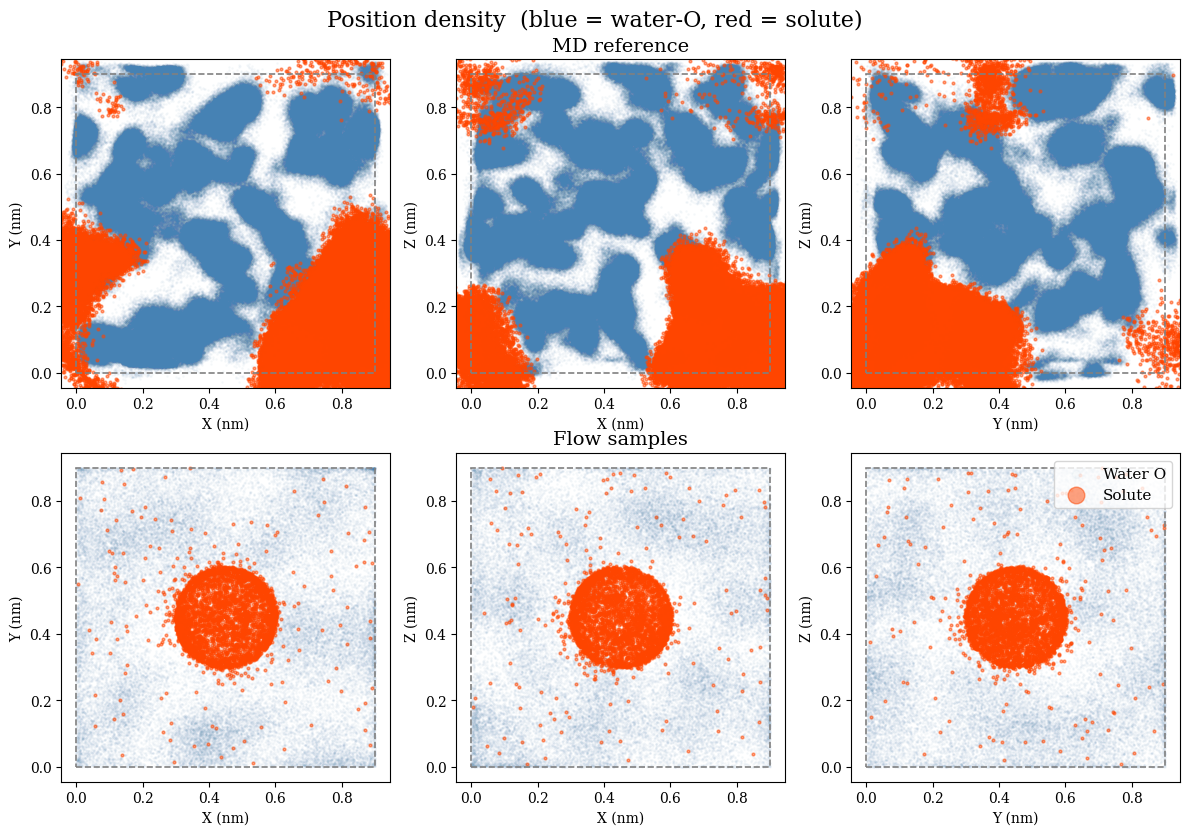

In [45]:
def _scatter_mol(axes_row, traj, subtitle, L, is_pbc=True):
    """
    traj : (N, N_ATOMS, 3)
    Plots water-O density and solute atoms in XY, XZ, YZ projections.
    """
    _proj_pairs = [(0, 1, "X (nm)", "Y (nm)"),
                   (0, 2, "X (nm)", "Z (nm)"),
                   (1, 2, "Y (nm)", "Z (nm)")]

    o_pos   = traj[:, O_IDX, :]   # (N, N_WATERS, 3)
    sol_pos = traj[:, :N_SOLUTE_ATOMS, :]  # (N, 3, 3)

    for ax, (i, j, xl, yl) in zip(axes_row, _proj_pairs):
        ax.scatter(o_pos[:, :, i].ravel(), o_pos[:, :, j].ravel(),
                   s=1, c="steelblue", alpha=0.03, label="Water O")
        ax.scatter(sol_pos[:, :, i].ravel(), sol_pos[:, :, j].ravel(),
                   s=4, c="orangered", alpha=0.5, label="Solute")
        if is_pbc:
            ax.add_patch(plt.Rectangle((0, 0), L, L,
                                       fill=False, ec="gray", ls="--", lw=1.2))
            ax.set_xlim(-0.05 * L, 1.05 * L)
            ax.set_ylim(-0.05 * L, 1.05 * L)
        ax.set_aspect("equal")
        ax.set_xlabel(xl, fontsize=10)
        ax.set_ylabel(yl, fontsize=10)

    axes_row[1].set_title(subtitle, fontsize=14)


_datasets = [(x_flow, "Flow samples")]
if x_md is not None:
    _datasets.insert(0, (x_md, "MD reference"))

n_ds = len(_datasets)
fig, axes = plt.subplots(n_ds, 3, figsize=(12, 4.2 * n_ds), squeeze=False)
for row_idx, (_traj, _sub) in enumerate(_datasets):
    _scatter_mol(axes[row_idx], _traj, _sub, L, is_pbc=IS_PBC)
axes[-1, -1].legend(markerscale=6, loc="upper right", fontsize=11)
fig.suptitle("Position density  (blue = water-O, red = solute)", fontsize=16)
plt.tight_layout()
plt.show()


### 6.2  3-D water-oxygen density heatmaps (XY / XZ / YZ)

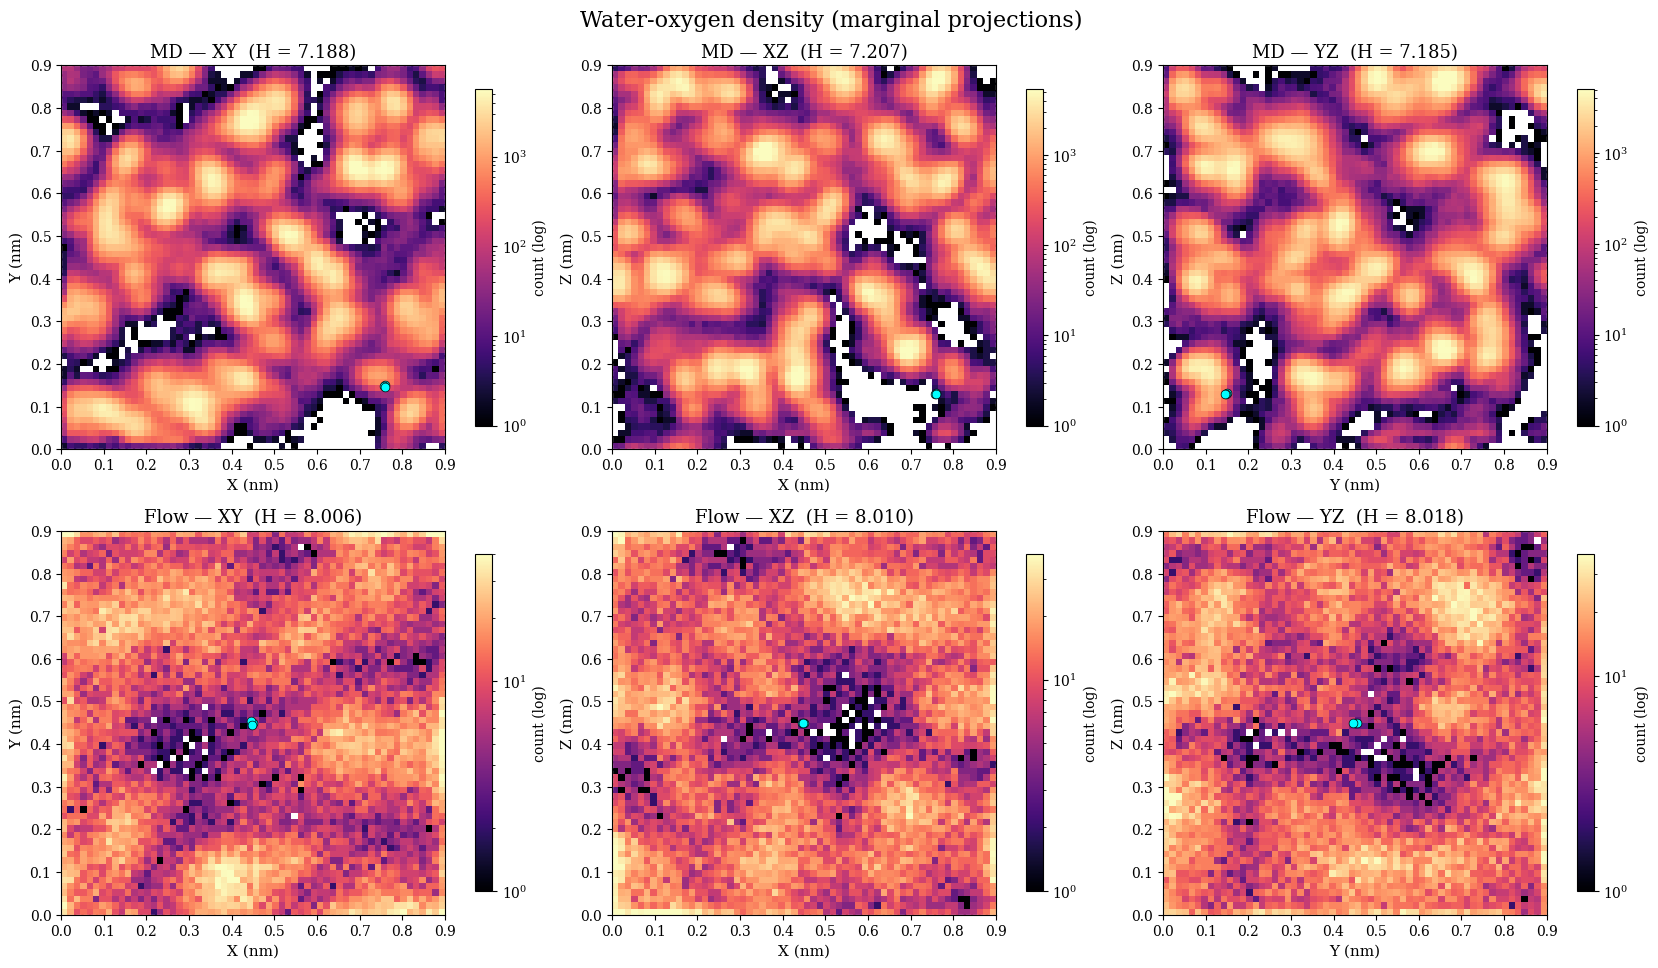

In [46]:
def _oxy_hist2d(traj, axis_drop, n_bins=60, L=None):
    """2-D marginal of water-oxygen positions (collapse one axis)."""
    keep = [a for a in range(3) if a != axis_drop]
    oxy  = traj[:, O_IDX, :].reshape(-1, 3)
    H, _, _ = np.histogram2d(
        oxy[:, keep[0]], oxy[:, keep[1]],
        bins=n_bins, range=[[0, L], [0, L]] if L else None,
    )
    p = H / H.sum()
    entropy = float(-np.sum(p[p > 0] * np.log(p[p > 0])))
    return H, entropy


_proj_labels = [
    (2, "XY", "X (nm)", "Y (nm)"),
    (1, "XZ", "X (nm)", "Z (nm)"),
    (0, "YZ", "Y (nm)", "Z (nm)"),
]

_panel_data = [(x_flow, "Flow")]
if x_md is not None:
    _panel_data.insert(0, (x_md, "MD"))

n_ds   = len(_panel_data)
n_proj = len(_proj_labels)
_Lplot = L if IS_PBC else None

fig, axes = plt.subplots(n_ds, n_proj,
                          figsize=(5.5 * n_proj, 4.8 * n_ds),
                          constrained_layout=True, squeeze=False)
for row, (_traj, _ds_lbl) in enumerate(_panel_data):
    for col, (axis_drop, proj_name, xl, yl) in enumerate(_proj_labels):
        H, S = _oxy_hist2d(_traj, axis_drop=axis_drop, n_bins=60, L=_Lplot)
        _pos = H[H > 0]
        _norm = LogNorm(vmin=max(1, np.percentile(_pos, 1)),
                        vmax=max(2, np.percentile(_pos, 99.5)))
        ax = axes[row, col]
        _keep = [a for a in range(3) if a != axis_drop]
        ext = (0, L, 0, L) if IS_PBC else None
        im = ax.imshow(H.T, origin="lower", extent=ext,
                       aspect="equal", cmap="magma", norm=_norm)
        # Mark solute positions
        for si in range(N_SOLUTE_ATOMS):
            ax.scatter(
                _traj[:, si, _keep[0]].mean(),
                _traj[:, si, _keep[1]].mean(),
                s=40, c="cyan", edgecolors="black", linewidths=0.5, zorder=3,
            )
        if IS_PBC:
            ax.add_patch(plt.Rectangle((0, 0), L, L,
                                       fill=False, ec="white", ls="--",
                                       lw=1.0, alpha=0.7))
        ax.set_title(f"{_ds_lbl} — {proj_name}  (H = {S:.3f})", fontsize=13)
        ax.set_xlabel(xl, fontsize=11)
        ax.set_ylabel(yl, fontsize=11)
        fig.colorbar(im, ax=ax, shrink=0.85).set_label("count (log)", fontsize=10)

fig.suptitle("Water-oxygen density (marginal projections)", fontsize=16)
plt.show()


### 6.3  Solute–water and water–water RDF (3-D)

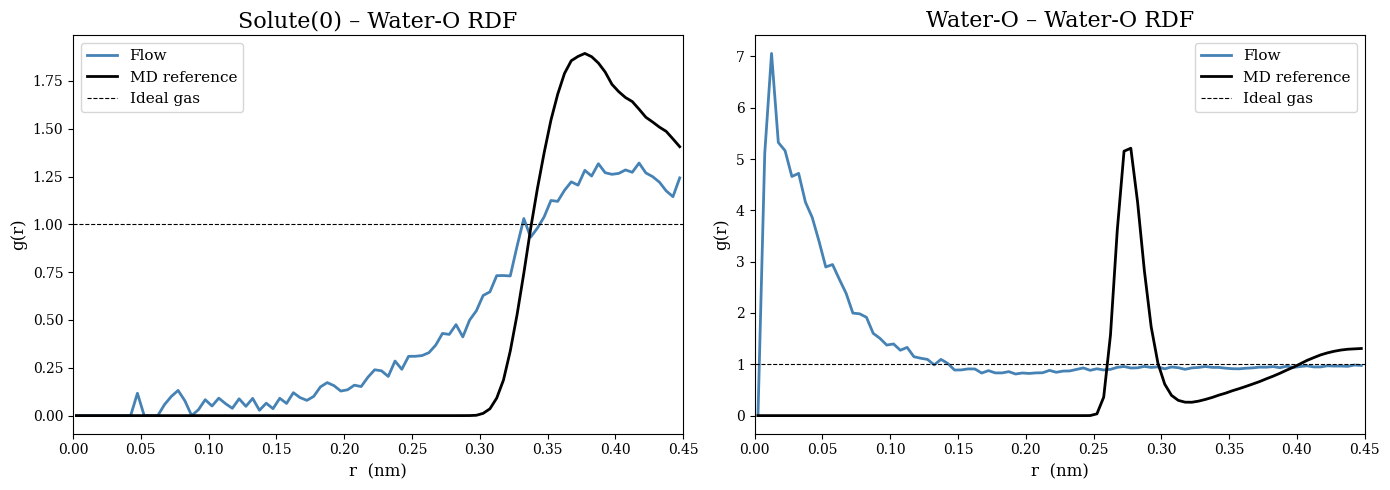

In [47]:
def compute_rdf_3d_atoms(traj, ref_idx, target_idx, L, dr=0.01):
    """
    3-D RDF g(r) between two sets of atom indices, with MIC for PBC.

    traj       : (N, N_ATOMS, 3)
    ref_idx    : list of atom indices for the reference group
    target_idx : list of atom indices for the target group
    L          : box length (nm); set to None for droplet (no MIC)
    """
    N   = traj.shape[0]
    ref  = traj[:, ref_idx, :]      # (N, n_ref, 3)
    tgt  = traj[:, target_idx, :]   # (N, n_tgt, 3)

    diff = tgt[:, None, :, :] - ref[:, :, None, :]  # (N, n_ref, n_tgt, 3)
    if L is not None:
        diff -= L * np.round(diff / L)
    r = np.linalg.norm(diff, axis=-1).ravel()

    r_max  = (0.5 * L) if L is not None else r.max()
    n_bins = int(np.floor(r_max / dr))
    edges  = np.linspace(0.0, n_bins * dr, n_bins + 1)
    counts, _ = np.histogram(r, bins=edges)

    r_c    = 0.5 * (edges[:-1] + edges[1:])
    shell  = 4.0 * np.pi * r_c**2 * dr
    vol    = (L**3) if L is not None else (4/3 * np.pi * r_max**3)
    rho    = len(target_idx) / vol
    expected = N * len(ref_idx) * rho * shell

    g_r = counts / np.maximum(expected, 1e-12)
    g_r[0] = 0.0
    return r_c, g_r


_L_rdf = L if IS_PBC else None

# Solute atom 0 → water oxygens
r_sw_flow, g_sw_flow = compute_rdf_3d_atoms(x_flow, [0], O_IDX, _L_rdf, dr=0.005)
# Water-oxygen → water-oxygen
r_ww_flow, g_ww_flow = compute_rdf_3d_atoms(x_flow, O_IDX, O_IDX, _L_rdf, dr=0.005)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (r_fl, g_fl, _title, _r_md, _g_md) in zip(axes, [
    (r_sw_flow, g_sw_flow, "Solute(0) – Water-O RDF", None, None),
    (r_ww_flow, g_ww_flow, "Water-O – Water-O RDF",   None, None),
]):
    ax.plot(r_fl, g_fl, lw=2, color="steelblue", label="Flow")
    if x_md is not None:
        if _title.startswith("Solute"):
            _r, _g = compute_rdf_3d_atoms(x_md, [0], O_IDX, _L_rdf, dr=0.005)
        else:
            _r, _g = compute_rdf_3d_atoms(x_md, O_IDX, O_IDX, _L_rdf, dr=0.005)
        ax.plot(_r, _g, lw=2, color="black", label="MD reference")
    ax.axhline(1.0, color="k", ls="--", lw=0.8, label="Ideal gas")
    ax.set_xlabel("r  (nm)", fontsize=12)
    ax.set_ylabel("g(r)", fontsize=12)
    ax.set_title(_title, fontsize=16)
    if _L_rdf:
        ax.set_xlim(0, 0.5 * L)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


### 6.4  O–O pairwise distance distributions

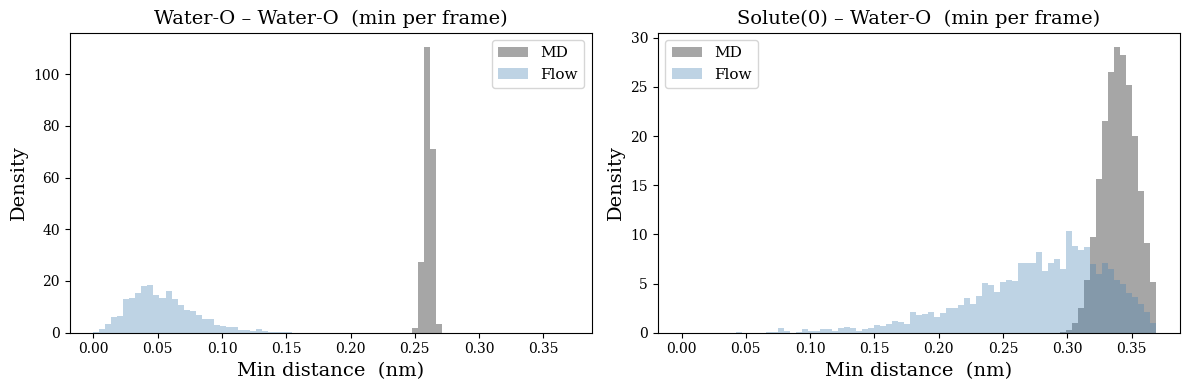

In [48]:
def min_oo_dist(traj, L, is_pbc=True):
    """Minimum water O-O distance per frame. traj: (N, N_ATOMS, 3)."""
    oxy = traj[:, O_IDX, :]   # (N, N_WATERS, 3)
    diff = oxy[:, :, None, :] - oxy[:, None, :, :]  # (N, W, W, 3)
    if is_pbc:
        diff -= L * np.round(diff / L)
    d = np.linalg.norm(diff, axis=-1)               # (N, W, W)
    eye = np.eye(d.shape[1], dtype=bool)[None, :, :]
    d   = np.where(eye, np.inf, d)
    return d.min(axis=(1, 2))


def sol_oo_dist(traj, L, is_pbc=True):
    """Minimum solute-atom-0 to water-O distance per frame."""
    sol = traj[:, 0:1, :]      # (N, 1, 3)
    oxy = traj[:, O_IDX, :]    # (N, W, 3)
    diff = oxy - sol            # (N, W, 3)
    if is_pbc:
        diff -= L * np.round(diff / L)
    d = np.linalg.norm(diff, axis=-1)  # (N, W)
    return d.min(axis=1)


d_ww_flow = min_oo_dist(x_flow, L, IS_PBC)
d_sw_flow = sol_oo_dist(x_flow, L, IS_PBC)

_pairs = [("Flow", d_ww_flow, d_sw_flow)]
if x_md is not None:
    _pairs.insert(0, ("MD", min_oo_dist(x_md, L, IS_PBC),
                          sol_oo_dist(x_md, L, IS_PBC)))

_colors = ["black", "steelblue"]
_all  = np.concatenate([v for _, a, b in _pairs for v in [a, b]])
_bins = np.linspace(0, np.nanpercentile(_all[np.isfinite(_all)], 99), 80)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for _ax, (_key, _stitle) in zip(axes, [
    ("ww", "Water-O – Water-O  (min per frame)"),
    ("sw", "Solute(0) – Water-O  (min per frame)"),
]):
    for _i, (_lbl, _dww, _dsw) in enumerate(_pairs):
        _d = _dww if _key == "ww" else _dsw
        _ax.hist(_d, bins=_bins, density=True, alpha=0.35,
                 color=_colors[_i % 2], label=_lbl, histtype="stepfilled")
    _ax.set_xlabel("Min distance  (nm)", fontsize=14)
    _ax.set_ylabel("Density", fontsize=14)
    _ax.set_title(_stitle, fontsize=14)
    _ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


### 6.5  Bond lengths and H–O–H angles

/Users/fleurdolmans/miniconda3/envs/bgsol/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/fleurdolmans/miniconda3/envs/bgsol/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


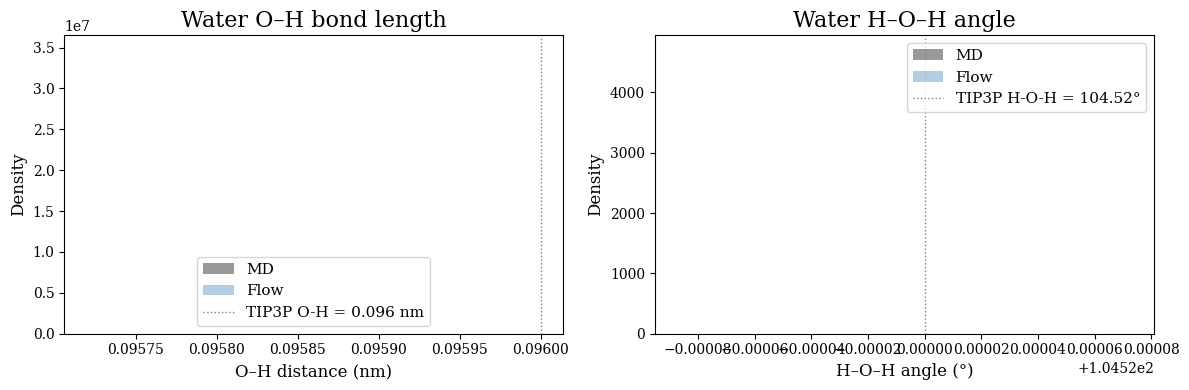

In [49]:
def _mic_vec(a, b, L, is_pbc):
    d = b - a
    if is_pbc:
        d -= L * np.round(d / L)
    return d

def water_bonds_and_angles(traj, L, is_pbc):
    """
    Returns O-H bond lengths (nm) and H-O-H angles (degrees) for all water molecules.
    """
    oh_lengths, hoh_angles = [], []
    for k in range(N_WATERS):
        o  = traj[:, O_IDX[k],  :]
        h1 = traj[:, H1_IDX[k], :]
        h2 = traj[:, H2_IDX[k], :]

        oh1 = np.linalg.norm(_mic_vec(o, h1, L, is_pbc), axis=-1)
        oh2 = np.linalg.norm(_mic_vec(o, h2, L, is_pbc), axis=-1)
        oh_lengths.append(oh1)
        oh_lengths.append(oh2)

        v1 = _mic_vec(o, h1, L, is_pbc)
        v2 = _mic_vec(o, h2, L, is_pbc)
        cos_a = (v1 * v2).sum(-1) / (
            np.linalg.norm(v1, axis=-1) * np.linalg.norm(v2, axis=-1) + 1e-12
        )
        hoh_angles.append(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))

    return np.concatenate(oh_lengths), np.concatenate(hoh_angles)


oh_flow, hoh_flow = water_bonds_and_angles(x_flow, L, IS_PBC)

_datasets_mol = [("Flow", oh_flow, hoh_flow, "steelblue")]
if x_md is not None:
    oh_md, hoh_md = water_bonds_and_angles(x_md, L, IS_PBC)
    _datasets_mol.insert(0, ("MD", oh_md, hoh_md, "black"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for _lbl, _oh, _hoh, _c in _datasets_mol:
    axes[0].hist(_oh, bins=80, density=True, alpha=0.4, color=_c,
                 histtype="stepfilled", label=_lbl)
    axes[1].hist(_hoh, bins=80, density=True, alpha=0.4, color=_c,
                 histtype="stepfilled", label=_lbl)

axes[0].axvline(0.096, color="gray", ls=":", lw=1.0, label="TIP3P O-H = 0.096 nm")
axes[1].axvline(104.52, color="gray", ls=":", lw=1.0, label="TIP3P H-O-H = 104.52°")
axes[0].set_xlabel("O–H distance (nm)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].set_title("Water O–H bond length", fontsize=16)
axes[0].legend(fontsize=11)
axes[1].set_xlabel("H–O–H angle (°)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].set_title("Water H–O–H angle", fontsize=16)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()


### 6.6  Energy distributions

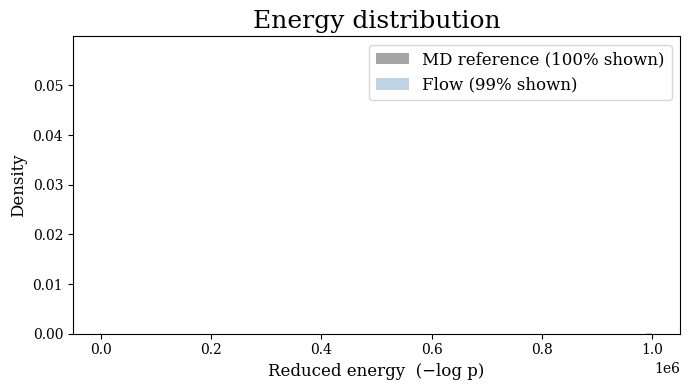

In [50]:
_finite_flow = u_flow[np.isfinite(u_flow)]
x_max_e = float(np.percentile(_finite_flow, 99))
if u_md is not None:
    x_max_e = max(x_max_e, float(np.percentile(u_md[np.isfinite(u_md)], 99)))

_energy_sets = [(u_flow, "Flow", "steelblue")]
if u_md is not None:
    _energy_sets.insert(0, (u_md, "MD reference", "black"))

fig, ax = plt.subplots(figsize=(7, 4))
for _e, _lbl, _c in _energy_sets:
    _ep   = _e[_e < x_max_e]
    _frac = len(_ep) / len(_e) * 100
    ax.hist(_ep, bins=80, density=True, alpha=0.35, color=_c,
            label=f"{_lbl} ({_frac:.0f}% shown)")

ax.set_xlabel("Reduced energy  (−log p)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Energy distribution", fontsize=18)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


### 6.7  Snapshot gallery (3-D scatter view)

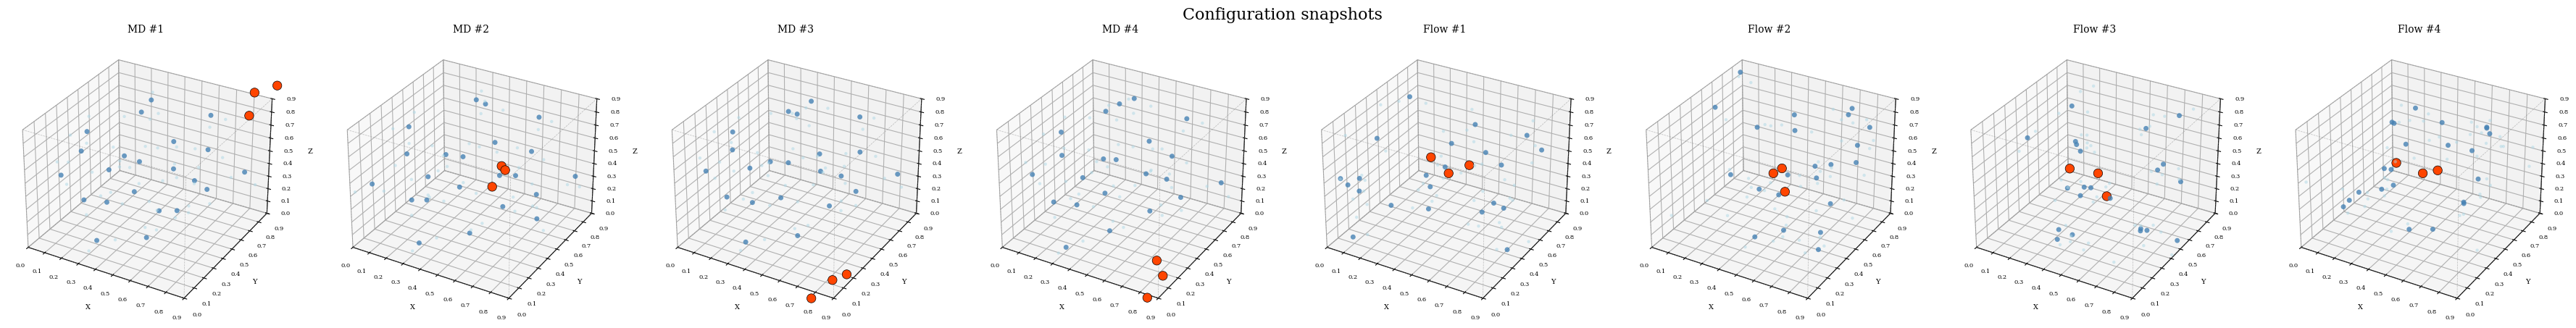

In [51]:
N_SNAP = 4

def draw_mol_snapshot(ax3d, pos, title=None, L=None):
    """
    pos : (N_ATOMS, 3) — one configuration
    Colours: solute=orangered, water-O=steelblue, water-H=lightblue
    """
    o_pos  = pos[O_IDX]
    h_pos  = pos[H1_IDX + H2_IDX]
    sol    = pos[:N_SOLUTE_ATOMS]

    ax3d.scatter(*h_pos.T,  s=10, c="lightblue",  alpha=0.5, edgecolors="none")
    ax3d.scatter(*o_pos.T,  s=25, c="steelblue",  alpha=0.8, edgecolors="none",  label="Water O")
    ax3d.scatter(*sol.T,    s=80, c="orangered",  alpha=1.0, edgecolors="black", linewidths=0.5, label="Solute")

    if L is not None:
        for _i in range(2):
            for _j in range(2):
                ax3d.plot([0, L], [_i*L, _i*L], [_j*L, _j*L], c="gray", ls="--", lw=0.5, alpha=0.5)
                ax3d.plot([_i*L, _i*L], [0, L], [_j*L, _j*L], c="gray", ls="--", lw=0.5, alpha=0.5)
                ax3d.plot([_i*L, _i*L], [_j*L, _j*L], [0, L], c="gray", ls="--", lw=0.5, alpha=0.5)
        ax3d.set_xlim(0, L); ax3d.set_ylim(0, L); ax3d.set_zlim(0, L)
    ax3d.set_xlabel("X", fontsize=7); ax3d.set_ylabel("Y", fontsize=7); ax3d.set_zlabel("Z", fontsize=7)
    ax3d.tick_params(labelsize=6)
    if title:
        ax3d.set_title(title, fontsize=10)


_sources = [(x_flow, "Flow")]
if x_md is not None:
    _sources.insert(0, (x_md, "MD"))

_ncols = N_SNAP * len(_sources)
fig = plt.figure(figsize=(4.5 * _ncols, 4.5))
_k = 0
for _src, _src_lbl in _sources:
    for _n in range(N_SNAP):
        ax3d = fig.add_subplot(1, _ncols, _k + 1, projection="3d")
        draw_mol_snapshot(ax3d, _src[_n], title=f"{_src_lbl} #{_n+1}",
                          L=L if IS_PBC else None)
        _k += 1

plt.suptitle("Configuration snapshots", fontsize=16)
plt.tight_layout()
plt.show()


### 6.8  Animated trajectory *(optional)*

KeyboardInterrupt: 

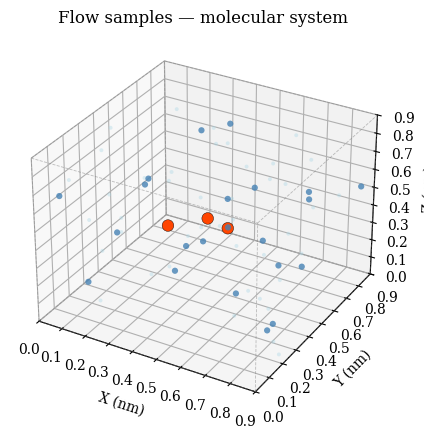

In [32]:
mpl.rcParams["animation.html"] = "jshtml"

N_ANIM = min(200, N_SAMPLES)
x_anim = x_flow[:N_ANIM]

fig  = plt.figure(figsize=(5, 5))
ax3d = fig.add_subplot(111, projection="3d")
if IS_PBC:
    ax3d.set_xlim(0, L); ax3d.set_ylim(0, L); ax3d.set_zlim(0, L)
ax3d.set_xlabel("X (nm)"); ax3d.set_ylabel("Y (nm)"); ax3d.set_zlabel("Z (nm)")
ax3d.set_title("Flow samples — molecular system")

if IS_PBC:
    for _i in range(2):
        for _j in range(2):
            ax3d.plot([0,L],[_i*L,_i*L],[_j*L,_j*L], c="gray",ls="--",lw=0.6,alpha=0.5)
            ax3d.plot([_i*L,_i*L],[0,L],[_j*L,_j*L], c="gray",ls="--",lw=0.6,alpha=0.5)
            ax3d.plot([_i*L,_i*L],[_j*L,_j*L],[0,L], c="gray",ls="--",lw=0.6,alpha=0.5)

sc_h   = ax3d.scatter([], [], [], s=8,  c="lightblue", alpha=0.4, edgecolors="none")
sc_o   = ax3d.scatter([], [], [], s=20, c="steelblue", alpha=0.8, edgecolors="none")
sc_sol = ax3d.scatter([], [], [], s=70, c="orangered", alpha=1.0,
                      edgecolors="black", linewidths=0.3)

def _upd(frame):
    pos = x_anim[frame]
    sc_h._offsets3d   = tuple(pos[H1_IDX + H2_IDX].T)
    sc_o._offsets3d   = tuple(pos[O_IDX].T)
    sc_sol._offsets3d = tuple(pos[:N_SOLUTE_ATOMS].T)
    return sc_h, sc_o, sc_sol

ani = animation.FuncAnimation(fig, _upd, frames=N_ANIM, interval=100, blit=False)

from IPython.display import display
display(ani)


# Evaluate ESS

In [52]:
# ── ESS sanity check ──────────────────────────────────────────────────────
import torch
import numpy as np
from scipy.special import logsumexp

n_check = 2000

with torch.no_grad():
    z_ess, log_q_t = flow.sample_and_log_prob((n_check,))
    log_p_t = target.log_prob(z_ess)

log_q = log_q_t.float().numpy()
log_p = log_p_t.float().numpy()
log_w = log_p - log_q        # importance weights in log space

finite_mask = np.isfinite(log_w)
log_w_f = log_w[finite_mask]
print(f"Finite samples: {finite_mask.sum()} / {n_check}  ({finite_mask.mean()*100:.1f}%)")

print("\n=== Log-density statistics ===")
print(f"log_q(z):  mean={log_q.mean():.2f}, std={log_q.std():.2f}")
lp_fin = log_p[np.isfinite(log_p)]
print(f"log_p(z):  mean={lp_fin.mean():.2f}, std={lp_fin.std():.2f}")
print(f"log_w:     mean={log_w_f.mean():.2f}, std={log_w_f.std():.2f}")

ess = np.exp(2 * logsumexp(log_w_f) - logsumexp(2 * log_w_f))
print(f"\nESS: {ess:.1f} / {n_check}  ({ess/n_check*100:.1f}%)")
print("(low std of log_w → high ESS → flow is well-calibrated)")

Finite samples: 2000 / 2000  (100.0%)

=== Log-density statistics ===
log_q(z):  mean=-26.13, std=23.25
log_p(z):  mean=-979488.88, std=119526.82
log_w:     mean=-979462.81, std=119529.55

ESS: 1.0 / 2000  (0.1%)
(low std of log_w → high ESS → flow is well-calibrated)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import logsumexp

n_check = 5000

with torch.no_grad():
    z_w, log_q_w_t = flow.sample_and_log_prob((n_check,))
    log_p_w_t = target.log_prob(z_w)

log_q_w = log_q_w_t.float().numpy()
log_p_w = log_p_w_t.float().numpy()
energies_w = -log_p_w           # reduced energy = -log p(z)
log_w = log_p_w - log_q_w       # importance weights in log space

finite_mask = np.isfinite(log_w)
log_w_f = log_w[finite_mask]
n_finite = int(finite_mask.sum())

# Normalize weights for cumulative-weight plot
log_w_norm = log_w_f - logsumexp(log_w_f)
w_norm = np.exp(log_w_norm)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Energy distribution (flow vs MD reference if available)
e_finite = energies_w[np.isfinite(energies_w)]
e_max = float(np.percentile(e_finite, 99))
axes[0].hist(e_finite[e_finite < e_max], bins=80, density=True,
             alpha=0.6, label='Flow', color='steelblue')
if u_md is not None:
    u_md_f = u_md[np.isfinite(u_md)]
    axes[0].hist(u_md_f[u_md_f < e_max], bins=40, density=True,
                 alpha=0.6, label='MD reference', color='black')
axes[0].set_xlabel('Energy (−log p)'); axes[0].set_ylabel('Density')
axes[0].set_title('Energy distribution'); axes[0].legend()

# 2. Distribution of log importance weights
axes[1].hist(log_w_f, bins=80, density=True, color='purple', alpha=0.7)
axes[1].axvline(np.median(log_w_f), color='k', ls='--',
                label=f'median={np.median(log_w_f):.1f}')
axes[1].set_xlabel('log w')
axes[1].set_title(f'log-weight distribution\nstd={log_w_f.std():.2f}')
axes[1].legend()

# 3. Cumulative weight: how many samples carry most of the weight?
w_sorted = np.sort(w_norm)[::-1]
cumw = np.cumsum(w_sorted)
axes[2].plot(np.arange(1, n_finite + 1), cumw)
axes[2].axhline(0.5, color='r', ls='--', label='50% of weight')
axes[2].axhline(0.9, color='orange', ls='--', label='90% of weight')
n50 = int(np.searchsorted(cumw, 0.5)) + 1
n90 = int(np.searchsorted(cumw, 0.9)) + 1
axes[2].set_xlabel('# samples (sorted by weight)')
axes[2].set_title(f'Cumulative weight\n50% in top {n50}, 90% in top {n90}')
axes[2].legend()

plt.tight_layout(); plt.show()

ess = np.exp(2 * logsumexp(log_w_f) - logsumexp(2 * log_w_f))
print(f"ESS: {ess:.1f} / {n_check}  ({ess/n_check*100:.1f}%)")
print(f"log_w: mean={log_w_f.mean():.2f}, std={log_w_f.std():.2f}")
print(f"50% of total weight in {n50}/{n_finite} samples ({n50/n_finite*100:.2f}%)")
print(f"90% of total weight in {n90}/{n_finite} samples ({n90/n_finite*100:.2f}%)")

In [ ]:
# ── Test 1: Boltzmann condition scatter ──────────────────────────────────────
# A perfect flow satisfies log q(z) ∝ log p(z), i.e. slope=1, Pearson r=1.
# The residual log q(z) − log p(z) is the log-normalisation constant log Z.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress

N_TEST = 3000

with torch.no_grad():
    z_bc, log_q_bc_t = flow.sample_and_log_prob((N_TEST,))
    log_p_bc_t = target.log_prob(z_bc)

log_q_bc = log_q_bc_t.float().numpy()
log_p_bc = log_p_bc_t.float().numpy()

finite_mask = np.isfinite(log_q_bc) & np.isfinite(log_p_bc)
log_q_f = log_q_bc[finite_mask]
log_p_f = log_p_bc[finite_mask]
log_w_f = log_p_f - log_q_f

r, _ = pearsonr(log_q_f, log_p_f)
slope, intercept, *_ = linregress(log_q_f, log_p_f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: log_q vs log_p
axes[0].scatter(log_q_f, log_p_f, s=2, alpha=0.3, c='steelblue')
lim_lo = max(log_q_f.min(), log_p_f.min()) - 5
lim_hi = min(log_q_f.max(), log_p_f.max()) + 5
axes[0].plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, label='slope=1 (ideal)')
fit_x = np.linspace(log_q_f.min(), log_q_f.max(), 100)
axes[0].plot(fit_x, slope * fit_x + intercept, 'r-', lw=1.5,
             label=f'fit slope={slope:.2f}')
axes[0].set_xlabel('log q(z)  [flow density]')
axes[0].set_ylabel('log p(z)  [Boltzmann]')
axes[0].set_title(f'Boltzmann condition\nPearson r={r:.3f}  (1.0 = perfect)')
axes[0].legend()

# Residuals: log_q(z) − log_p(z) ≈ log Z (should be ~constant)
residuals = log_q_f - log_p_f
axes[1].hist(residuals, bins=60, density=True, color='steelblue', alpha=0.7)
axes[1].set_xlabel('log q(z) − log p(z)')
axes[1].set_title(f'Residuals from Boltzmann\nmean={residuals.mean():.2f}, std={residuals.std():.2f}')
axes[1].axvline(residuals.mean(), color='r', ls='--', label='mean (≈ log Z)')
axes[1].legend()

plt.suptitle('Test 1: Boltzmann Condition', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Pearson r(log_q, log_p): {r:.4f}   (ideal=1.0, random≈0.0)")
print(f"Fit slope:               {slope:.4f}  (ideal=1.0)")
print(f"Residual std:            {residuals.std():.4f}  (= sqrt(Var[log_w]), ideal→0)")
print(f"Residual mean:           {residuals.mean():.2f}  (≈ log Z, the partition function)")

In [ ]:
# ── Test 2: Latent space quality (MD samples → base space) ──────────────────
# Encodes MD reference samples (internal coords) through the inverse flow
# to check whether they map to Gaussian(0,1) in the base (latent) space.
# Requires MD data: set MD_REF_PATH in cell 2 and re-run cells 3–5.
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

if target.val_data_i is None:
    print("Test 2 skipped: no MD reference data loaded.")
    print("Set MD_REF_PATH in cell 2 to the trajectory file and re-run.")
else:
    z_md = target.val_data_i.float().to(DEVICE)

    # Encode internal coords → base space by reversing each flow layer
    with torch.no_grad():
        h = z_md.clone()
        for layer in reversed(flow.flows):
            h, _ = layer.inverse(h)
        z_latent = h.cpu().float().numpy()    # (n_md, internal_dim)

    print(f"z_latent shape : {z_latent.shape}")
    print(f"z mean  : {z_latent.mean():.4f}  (ideal 0)")
    print(f"z std   : {z_latent.std():.4f}   (ideal 1)")

    n_coords = z_latent.shape[1]
    ks_stats = np.array([
        stats.kstest(z_latent[:, i], 'norm').statistic
        for i in range(n_coords)
    ])
    coord_means = z_latent.mean(axis=0)
    coord_stds  = z_latent.std(axis=0)

    top5 = np.argsort(ks_stats)[-5:]
    bar_colors = ['crimson' if i in top5 else 'purple' for i in range(n_coords)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].bar(range(n_coords), np.abs(coord_means),
                color='steelblue', alpha=0.7, label='|mean| (ideal 0)')
    axes[0].axhline(0.05, color='r', ls='--', label='0.05 threshold')
    axes[0].set_xlabel('Latent coordinate index'); axes[0].set_ylabel('|mean|')
    axes[0].set_title('Per-coordinate |mean| of z'); axes[0].legend()

    axes[1].bar(range(n_coords), coord_stds,
                color='orangered', alpha=0.7, label='std (ideal 1)')
    axes[1].axhline(1.0, color='k', ls='--', label='ideal std=1')
    axes[1].set_xlabel('Latent coordinate index'); axes[1].set_ylabel('std')
    axes[1].set_title('Per-coordinate std of z'); axes[1].legend()

    axes[2].bar(range(n_coords), ks_stats, color=bar_colors, alpha=0.8)
    axes[2].axhline(0.05, color='r', ls='--', label='KS=0.05 threshold')
    axes[2].set_xlabel('Latent coordinate index'); axes[2].set_ylabel('KS statistic')
    axes[2].set_title(
        f'Per-coord KS-test (crimson = top 5 worst)\n'
        f'max KS={ks_stats.max():.3f} at coord {int(ks_stats.argmax())}'
    )
    axes[2].legend()

    plt.suptitle('Test 2: Latent Space Quality (MD → z)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f"\nWorst 5 latent coordinates (KS statistic):")
    for i in sorted(top5):
        print(f"  coord {i:3d}: KS={ks_stats[i]:.4f}, mean={coord_means[i]:.4f}, "
              f"std={coord_stds[i]:.4f}")

In [ ]:
# ── Test 3: Per-layer log|det J| decomposition (normflows) ──────────────────
# Traces how the Jacobian log-determinant builds up across flow layers in the
# generative direction (base → internal coords).
# A layer with high Var(log|det|) dominates importance-weight variance.
import numpy as np
import matplotlib.pyplot as plt

N_TEST = 2000

# Sample from base distribution and trace through all flow layers
with torch.no_grad():
    z0, _ = flow.q0(N_TEST)
    z0 = z0.float()

per_layer_logdet = []
with torch.no_grad():
    h = z0.clone()
    for layer in flow.flows:
        h_new, ld = layer(h)
        per_layer_logdet.append(ld.float().numpy())
        h = h_new

per_layer_logdet  = np.array(per_layer_logdet)         # (n_layers, N_TEST)
cumulative_logdet = per_layer_logdet.cumsum(axis=0)
n_layers = len(per_layer_logdet)
x_ax = np.arange(n_layers)

layer_means = per_layer_logdet.mean(axis=1)
layer_stds  = per_layer_logdet.std(axis=1)
high_var = layer_stds > layer_stds.mean() + layer_stds.std()
bar_colors = ['crimson' if hv else 'steelblue' for hv in high_var]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Per-layer mean ± std
axes[0].bar(x_ax, layer_means, yerr=layer_stds, capsize=2,
            color=bar_colors, alpha=0.8)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_xlabel('Flow layer index'); axes[0].set_ylabel('log|det| (mean ± std)')
axes[0].set_title('Per-layer log|det J|\n(crimson = high-variance layers)')

# 2. Cumulative log|det| with spread
axes[1].fill_between(
    x_ax,
    cumulative_logdet.mean(1) - cumulative_logdet.std(1),
    cumulative_logdet.mean(1) + cumulative_logdet.std(1),
    alpha=0.3, color='orangered'
)
axes[1].plot(x_ax, cumulative_logdet.mean(1), 'r-o', markersize=3)
axes[1].set_xlabel('After layer k'); axes[1].set_ylabel('Cumulative log|det|')
axes[1].set_title('Cumulative log|det| mean ± std\n(wider = more weight variance)')

# 3. Variance per layer
top3 = np.argsort(layer_stds**2)[-3:]
vbar_colors = ['crimson' if i in top3 else 'purple' for i in range(n_layers)]
axes[2].bar(x_ax, layer_stds**2, color=vbar_colors, alpha=0.8)
axes[2].set_xlabel('Flow layer index'); axes[2].set_ylabel('Var(log|det|)')
axes[2].set_title(f'Variance per layer  (top 3: {sorted(top3)})')

plt.suptitle('Test 3: Per-Layer log|det J| Decomposition', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'Layer':>6} | {'mean':>8} | {'std':>8} | {'var':>8}")
print("-" * 42)
for i, (m, s) in enumerate(zip(layer_means, layer_stds)):
    flag = "  <-- HIGH VAR" if high_var[i] else ""
    print(f"{i:6d} | {m:8.3f} | {s:8.3f} | {s**2:8.3f}{flag}")
print(f"\nTotal cumulative log|det| std : {cumulative_logdet[-1].std():.3f}")
print(f"Sum of per-layer variances   : {(layer_stds**2).sum():.3f}")

In [ ]:
# ── Test 4: High-weight vs low-weight sample inspection ─────────────────────
# XY projection of 3D configurations sorted by importance weight.
# High-weight samples resemble the target; low-weight ones do not.
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

N_TEST = 5000

with torch.no_grad():
    z_t4, log_q_t4_t = flow.sample_and_log_prob((N_TEST,))
    log_p_t4_t = target.log_prob(z_t4)
    x_c_t4, _ = target.coordinate_transform.forward(z_t4)

log_q_t4 = log_q_t4_t.float().numpy()
log_p_t4 = log_p_t4_t.float().numpy()
energies_t4 = -log_p_t4
log_w_t4 = log_p_t4 - log_q_t4

finite_mask = np.isfinite(log_w_t4)
n_finite = int(finite_mask.sum())
log_w_f = log_w_t4[finite_mask]
x_cart_t4 = x_c_t4.float().cpu().numpy()[finite_mask].reshape(n_finite, N_ATOMS, 3)
e_f4 = energies_t4[finite_mask]

# Sort by weight (descending)
log_w_norm = log_w_f - logsumexp(log_w_f)
w_norm = np.exp(log_w_norm)
order = np.argsort(w_norm)[::-1]
x_sorted = x_cart_t4[order]
w_sorted = w_norm[order]
e_sorted = e_f4[order]

cumw = np.cumsum(w_sorted)
n50 = int(np.searchsorted(cumw, 0.5)) + 1
n90 = int(np.searchsorted(cumw, 0.9)) + 1
print(f"Top {n50}/{n_finite} samples ({n50/n_finite*100:.2f}%) carry 50% of total weight")
print(f"Top {n90}/{n_finite} samples ({n90/n_finite*100:.2f}%) carry 90% of total weight")
print(f"Energy of top-5 by weight: {[f'{v:.0f}' for v in e_sorted[:5]]}")


def _plot_config_xy(ax, pos, title, L=None):
    """XY projection of one configuration (N_ATOMS, 3)."""
    o_xy   = pos[O_IDX,  :2]
    sol_xy = pos[:N_SOLUTE_ATOMS, :2]
    ax.scatter(o_xy[:, 0], o_xy[:, 1], s=30, c='steelblue', alpha=0.7)
    ax.scatter(sol_xy[:, 0], sol_xy[:, 1], s=120, c='orangered',
               marker='*', zorder=5)
    if L is not None:
        ax.add_patch(plt.Rectangle((0, 0), L, L, fill=False, ec='gray', ls='--'))
        ax.set_xlim(-0.05*L, 1.05*L); ax.set_ylim(-0.05*L, 1.05*L)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=9)
    ax.set_xlabel('X (nm)'); ax.set_ylabel('Y (nm)')


fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row: 3 highest-weight samples
for col in range(3):
    _plot_config_xy(
        axes[0, col], x_sorted[col],
        f'High-weight #{col+1}\nE={e_sorted[col]:.0f},  w={w_sorted[col]*n_finite:.3f}×(1/N)',
        L=L if IS_PBC else None,
    )

# Bottom row: 3 random low-weight samples (bottom 25%)
rng = np.random.default_rng(42)
bottom_positions = rng.choice(np.arange(n_finite * 3 // 4, n_finite), 3, replace=False)
for col, pos in enumerate(bottom_positions):
    _plot_config_xy(
        axes[1, col], x_sorted[pos],
        f'Low-weight sample\nE={e_sorted[pos]:.0f},  w≈0',
        L=L if IS_PBC else None,
    )

axes[0, 0].set_ylabel('High-weight samples', fontsize=11)
axes[1, 0].set_ylabel('Low-weight samples', fontsize=11)
plt.suptitle('Test 4: High-weight vs Low-weight configurations (XY projection)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Energy histogram split by weight class
top10_mask = np.zeros(n_finite, dtype=bool)
top10_mask[order[:n_finite // 10]] = True
e_fin = e_f4[np.isfinite(e_f4)]
e_max_plot = float(np.percentile(e_fin, 99))
bins = np.linspace(float(e_fin.min()), e_max_plot, 60)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(e_f4[top10_mask & np.isfinite(e_f4)], bins=bins, density=True,
        alpha=0.6, label='Top 10% by weight', color='green')
ax.hist(e_f4[~top10_mask & np.isfinite(e_f4)], bins=bins, density=True,
        alpha=0.6, label='Bottom 90% by weight', color='gray')
if u_md is not None:
    u_md_fin = u_md[np.isfinite(u_md)]
    ax.hist(u_md_fin[u_md_fin < e_max_plot], bins=bins, density=True,
            alpha=0.6, label='MD reference', color='steelblue')
ax.set_xlabel('Energy (−log p)'); ax.set_title('Energy distribution by weight class')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ── Test 5: ESS scaling with sample size ────────────────────────────────────
# For a well-generalising flow, ESS/N stays roughly constant as N grows.
# A sharply decreasing ESS/N indicates "lottery ticket" behaviour where a
# tiny fraction of samples dominates the weights.
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

sample_sizes = [100, 250, 500, 1000, 2000, 5000]
ess_vals = []

for n in sample_sizes:
    with torch.no_grad():
        z_s, lq_s = flow.sample_and_log_prob((n,))
        lp_s = target.log_prob(z_s)
    lw = (lp_s - lq_s).float().numpy()
    lw_f = lw[np.isfinite(lw)]
    if len(lw_f) < 2:
        ess_vals.append(0.0)
    else:
        ess_vals.append(float(np.exp(2 * logsumexp(lw_f) - logsumexp(2 * lw_f))))

ess_frac = [e / n for e, n in zip(ess_vals, sample_sizes)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sample_sizes, ess_vals, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('N (sample size)'); axes[0].set_ylabel('ESS')
axes[0].set_title('Absolute ESS vs sample size')

axes[1].plot(sample_sizes, ess_frac, 'o-', color='steelblue', lw=2)
axes[1].axhline(ess_frac[0], color='gray', ls='--', alpha=0.5,
                label=f'first ESS/N = {ess_frac[0]:.3f}')
axes[1].set_xlabel('N (sample size)'); axes[1].set_ylabel('ESS / N')
axes[1].set_title('Relative ESS/N vs sample size\n(flat = good;  decreasing = weight collapse)')
axes[1].legend()

plt.suptitle('Test 5: ESS Scaling Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'N':>6} | {'ESS':>8} | {'ESS/N':>8}")
print("-" * 30)
for n, e, f in zip(sample_sizes, ess_vals, ess_frac):
    print(f"{n:6d} | {e:8.1f} | {f:8.4f}")